# Setup

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')


In [57]:
data = pd.read_csv('data_ver3.csv',encoding='utf-8')

In [58]:
#Transform the data into a dataframe
df = pd.DataFrame(data)

In [59]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         262 non-null    object 
 1   Strain          244 non-null    object 
 2   Condition_main  262 non-null    object 
 3   Compound        262 non-null    object 
 4   Label           260 non-null    object 
 5   BKT             262 non-null    int64  
 6   PDS             256 non-null    float64
 7   crtZ            256 non-null    float64
 8   ZDS             256 non-null    float64
 9   crtW            256 non-null    float64
 10  crtB            256 non-null    float64
 11  lcyB            256 non-null    float64
 12  BKT_TPM         262 non-null    float64
 13  PDS_TPM         256 non-null    float64
 14  crtZ_TPM        256 non-null    float64
 15  ZDS_TPM         256 non-null    float64
 16  crtW_TPM        256 non-null    float64
 17  lcyB_TPM        256 non-null    flo

In [100]:
df['Species'].value_counts()

Species
Chromochloris zofingiensis    97
Haematococcus pluvialis       96
Chlorella sorokiniana         32
Dunaliella salina             18
Chlamydomonas reinhardtii      9
Haematococcus lacustris        4
Name: count, dtype: int64

# Data Preparation

## 1.Handle Null data

In [60]:
#Check for missing values
print(df.isnull().sum())

Species            0
Strain            18
Condition_main     0
Compound           0
Label              2
BKT                0
PDS                6
crtZ               6
ZDS                6
crtW               6
crtB               6
lcyB               6
BKT_TPM            0
PDS_TPM            6
crtZ_TPM           6
ZDS_TPM            6
crtW_TPM           6
lcyB_TPM           6
crtB_TPM           6
dtype: int64


In [61]:
null_rows = df[df['Label'].isnull()]
print(null_rows)

                      Species Strain Condition_main    Compound Label  BKT  \
260  Nannochloropsis oceanica  IMET1          Light  B-carotene   NaN    0   
261  Nannochloropsis oceanica  IMET1          Light  B-carotene   NaN    0   

     PDS  crtZ  ZDS  crtW  crtB  lcyB  BKT_TPM  PDS_TPM  crtZ_TPM  ZDS_TPM  \
260  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   
261  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   

     crtW_TPM  lcyB_TPM  crtB_TPM  
260       NaN       NaN       NaN  
261       NaN       NaN       NaN  


In [62]:
# Drop rows with null values in the Label column
df = df.dropna(subset=['Label'])

In [63]:
# Fill missing values in the Strain column with 'Unknown'
df['Strain'] = df['Strain'].fillna('Unknown')
print("Missing values in Strain:", df['Strain'].isnull().sum())

Missing values in Strain: 0


In [64]:
null_rows = df[df['crtZ'].isnull()]
print(null_rows)

                      Species Strain Condition_main    Compound   Label  BKT  \
256  Nannochloropsis oceanica  IMET1          Light  B-carotene  Medium    0   
257  Nannochloropsis oceanica  IMET1          Light  B-carotene  Medium    0   
258  Nannochloropsis oceanica  IMET1          Light  B-carotene    High    0   
259  Nannochloropsis oceanica  IMET1          Light  B-carotene    High    0   

     PDS  crtZ  ZDS  crtW  crtB  lcyB  BKT_TPM  PDS_TPM  crtZ_TPM  ZDS_TPM  \
256  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   
257  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   
258  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   
259  NaN   NaN  NaN   NaN   NaN   NaN      0.0      NaN       NaN      NaN   

     crtW_TPM  lcyB_TPM  crtB_TPM  
256       NaN       NaN       NaN  
257       NaN       NaN       NaN  
258       NaN       NaN       NaN  
259       NaN       NaN       NaN  


In [65]:
df = df.dropna(subset=['crtZ'])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 255
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         256 non-null    object 
 1   Strain          256 non-null    object 
 2   Condition_main  256 non-null    object 
 3   Compound        256 non-null    object 
 4   Label           256 non-null    object 
 5   BKT             256 non-null    int64  
 6   PDS             256 non-null    float64
 7   crtZ            256 non-null    float64
 8   ZDS             256 non-null    float64
 9   crtW            256 non-null    float64
 10  crtB            256 non-null    float64
 11  lcyB            256 non-null    float64
 12  BKT_TPM         256 non-null    float64
 13  PDS_TPM         256 non-null    float64
 14  crtZ_TPM        256 non-null    float64
 15  ZDS_TPM         256 non-null    float64
 16  crtW_TPM        256 non-null    float64
 17  lcyB_TPM        256 non-null    float64


## 2.Cleaning data

In [67]:
#Cleaning categorical columns by removing newline characters and stripping whitespace
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.replace('\n', '', regex=False).str.strip()

In [68]:
df.head()

,Species,Strain,Condition_main,Compound,Label,BKT,PDS,crtZ,ZDS,crtW,crtB,lcyB,BKT_TPM,PDS_TPM,crtZ_TPM,ZDS_TPM,crtW_TPM,lcyB_TPM,crtB_TPM
0,Haematococcus pluvialis,NBU489,Chemical_treatment,astaxanthin,High,1,1.0,1.0,1.0,1.0,1.0,1.0,948.69,332.12,140.50,163.77,316.23,337.59,303.01
1,Haematococcus pluvialis,NBU489,Chemical_treatment,astaxanthin,High,1,1.0,1.0,1.0,1.0,1.0,1.0,1118.79,356.98,180.26,176.88,372.93,332.75,328.49
2,Haematococcus pluvialis,NBU489,Chemical_treatment,astaxanthin,High,1,1.0,1.0,1.0,1.0,1.0,1.0,912.03,315.34,135.95,122.87,304.01,236.36,229.38
3,Haematococcus pluvialis,NBU489,Chemical_treatment,astaxanthin,High,1,1.0,1.0,1.0,1.0,1.0,1.0,1197.30,447.42,128.45,193.82,399.10,440.16,273.64
4,Haematococcus pluvialis,NBU489,Chemical_treatment,astaxanthin,High,1,1.0,1.0,1.0,1.0,1.0,1.0,939.54,369.59,133.20,175.01,313.18,371.56,302.07


# EDA

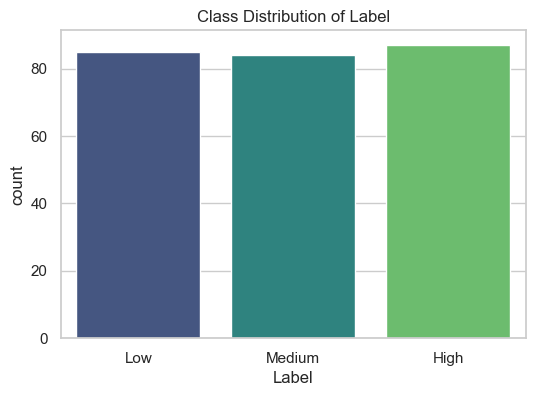

In [69]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label', order=['Low', 'Medium', 'High'],palette='viridis')
plt.title('Class Distribution of Label')
plt.show()

In [70]:
df['Label'].value_counts()

Label
High      87
Low       85
Medium    84
Name: count, dtype: int64

พบยีนทั้งหมด 7 ตัว ได้แก่: ['BKT_TPM', 'PDS_TPM', 'crtZ_TPM', 'ZDS_TPM', 'crtW_TPM', 'lcyB_TPM', 'crtB_TPM']


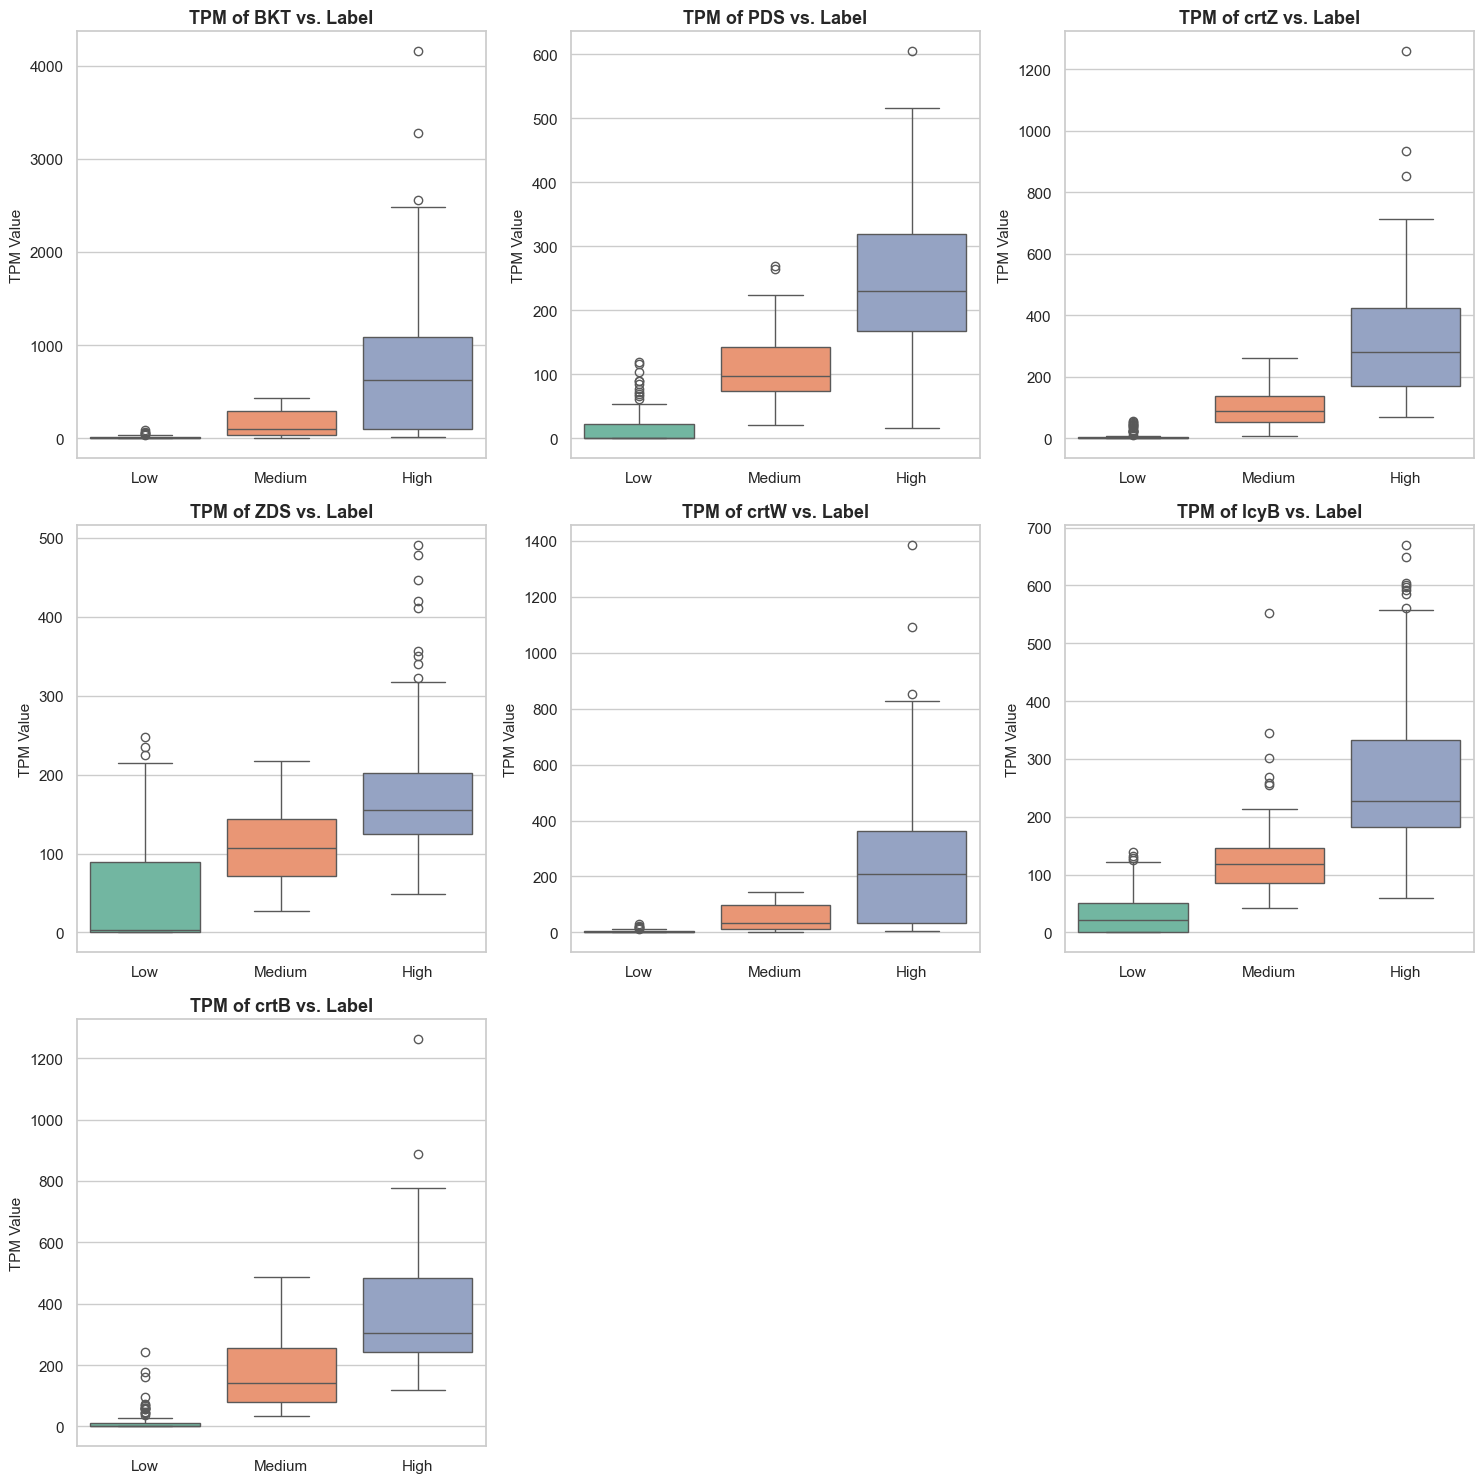

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

tpm_cols = [col for col in df.columns if '_TPM' in col]
num_genes = len(tpm_cols)

print(f"พบยีนทั้งหมด {num_genes} ตัว ได้แก่: {tpm_cols}")


cols_per_row = 3
rows = math.ceil(num_genes / cols_per_row)


fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))

axes = axes.flatten()


for i, col_name in enumerate(tpm_cols):
    # วาด Boxplot ลงในช่องที่ i
    sns.boxplot(
        data=df, 
        x='Label', 
        y=col_name, 
        order=['Low', 'Medium', 'High'], 
        ax=axes[i], 
        palette='Set2' # เปลี่ยนสีได้ เช่น 'Set3', 'viridis', 'coolwarm'
    )
    
    # ตัดคำว่า '_TPM' ออกจากชื่อบนหัวกราฟเพื่อความสวยงาม
    gene_name = col_name.replace('_TPM', '')
    
    # ตั้งชื่อหัวกราฟและแกน Y
    axes[i].set_title(f'TPM of {gene_name} vs. Label', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('TPM Value', fontsize=11)
    axes[i].set_xlabel('')


for j in range(num_genes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Heat Map shows relation between each gene expression

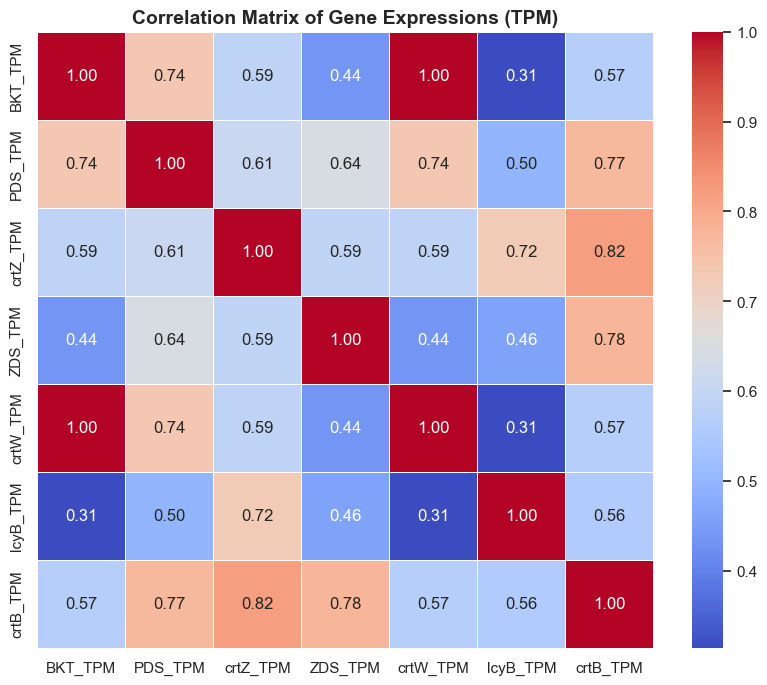

In [72]:
# เลือกเฉพาะคอลัมน์ที่ลงท้ายด้วย _TPM
tpm_cols = [col for col in df.columns if '_TPM' in col]

plt.figure(figsize=(10, 8))
corr_matrix = df[tpm_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Gene Expressions (TPM)', fontsize=14, fontweight='bold')
plt.show()

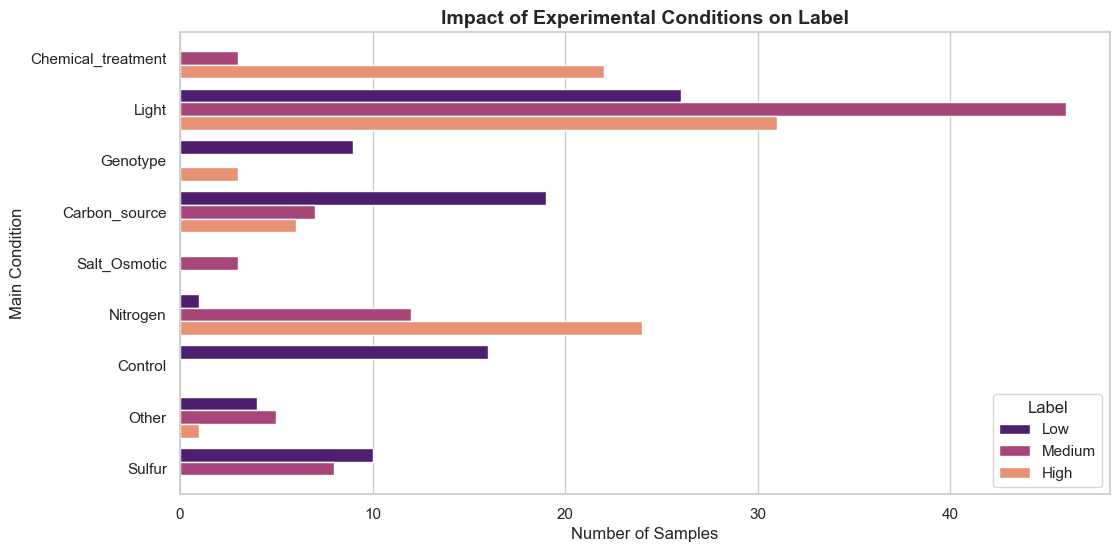

In [73]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Condition_main', hue='Label', hue_order=['Low', 'Medium', 'High'], palette='magma')
plt.title('Impact of Experimental Conditions on Label', fontsize=14, fontweight='bold')
plt.xlabel('Number of Samples')
plt.ylabel('Main Condition')
plt.legend(title='Label', loc='lower right')
plt.show()

# Data Preprocessing

## 1.Feature Selection

In [74]:
# Define the target column
target_col = 'Label'
# Delete unnecessary columns
cols_to_drop = ['Strain']
df = df.drop(columns=cols_to_drop)

X = df

## 2.Seperate taget columns

In [75]:
#Separate X and Y
X = X.drop(columns=[target_col])
Y = df[target_col]

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 255
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         256 non-null    object 
 1   Condition_main  256 non-null    object 
 2   Compound        256 non-null    object 
 3   Label           256 non-null    object 
 4   BKT             256 non-null    int64  
 5   PDS             256 non-null    float64
 6   crtZ            256 non-null    float64
 7   ZDS             256 non-null    float64
 8   crtW            256 non-null    float64
 9   crtB            256 non-null    float64
 10  lcyB            256 non-null    float64
 11  BKT_TPM         256 non-null    float64
 12  PDS_TPM         256 non-null    float64
 13  crtZ_TPM        256 non-null    float64
 14  ZDS_TPM         256 non-null    float64
 15  crtW_TPM        256 non-null    float64
 16  lcyB_TPM        256 non-null    float64
 17  crtB_TPM        256 non-null    float64


## 3. Encoding

### One-Hot Encoding

In [77]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [78]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 0 to 255
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   BKT                                 256 non-null    int64  
 1   PDS                                 256 non-null    float64
 2   crtZ                                256 non-null    float64
 3   ZDS                                 256 non-null    float64
 4   crtW                                256 non-null    float64
 5   crtB                                256 non-null    float64
 6   lcyB                                256 non-null    float64
 7   BKT_TPM                             256 non-null    float64
 8   PDS_TPM                             256 non-null    float64
 9   crtZ_TPM                            256 non-null    float64
 10  ZDS_TPM                             256 non-null    float64
 11  crtW_TPM                            256 non-null  

### Label Encoder

In [79]:
# To change Label(High,Medium,Low) to numerical values (0,1,2)
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

print(f"Label classes: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(Y_encoded)}")

Label classes: ['High' 'Low' 'Medium']
Encoded labels: [0 1 2]


## 4.Train Test split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded
)

## 5. Data scaling

In [81]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (204, 31), X_test shape: (52, 31)


# Model

## Import Model

In [82]:
# Model training for multiple classifiers: LogisticRegression, QDA, KNN, ANN, SVC, RandomForest, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC    # ->SVM
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Keras / TensorFlow for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## Model Trainning

In [83]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)


n_classes = len(np.unique(y_train))

results = {}

### Logistic Regression

In [84]:
# 1) Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results['LogisticRegression'] = {
    'model': lr,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base logistic regression (multiclass)
lr = LogisticRegression(random_state=42)

# Parameter grid with solver-safe combinations
param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'multi_class': ['multinomial'],
        'max_iter': [1000]
    },
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'multi_class': ['ovr'],
        'max_iter': [1000]
    }
]

# Grid search
lr_grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)
print("Best CV score:", lr_grid.best_score_)

# Test evaluation
y_pred = best_lr.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 38 candidates, totalling 190 fits
Best params: {'C': 100, 'max_iter': 1000, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'sag'}
Best CV score: 0.9608536585365852
Test Accuracy: 0.8846153846153846

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.93      0.82      0.88        17
           2       0.79      0.88      0.83        17

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.89        52

Confusion Matrix:
 [[17  0  1]
 [ 0 14  3]
 [ 1  1 15]]
Train CV scores: [0.95121951 0.97560976 0.95121951 0.95121951 0.975     ]
Train CV mean: 0.9608536585365852


### SVM

In [86]:
# 4) Support Vector Classifier
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
results['SVC'] = {
    'model': svc,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}


In [87]:
# ...existing code...
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base SVC and hyperparameter grid
svc = SVC(probability=True, random_state=42)
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Grid search with 5-fold CV
svc_grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid.fit(X_train_scaled, y_train)

# Best estimator and CV score
best_svc = svc_grid.best_estimator_
print("Best params:", svc_grid.best_params_)
print("Best CV score:", svc_grid.best_score_)

# Evaluate on test set
y_pred = best_svc.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_svc, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.965731707317073
Test Accuracy: 0.9038461538461539

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.94      0.88      0.91        17
           2       0.83      0.88      0.86        17

    accuracy                           0.90        52
   macro avg       0.91      0.90      0.90        52
weighted avg       0.91      0.90      0.90        52

Confusion Matrix:
 [[17  0  1]
 [ 0 15  2]
 [ 1  1 15]]
Train CV scores: [0.95121951 0.97560976 0.95121951 0.97560976 0.975     ]
Train CV mean: 0.965731707317073


### QDA

In [88]:
# 2) Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred = qda.predict(X_test_scaled)
results['QDA'] = {
    'model': qda,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [89]:
# ...existing code...
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base QDA
qda = QuadraticDiscriminantAnalysis()

# Parameter grid (regularization + optional covariance storage / tolerance)
param_grid = {
    'reg_param': [0.0, 0.001, 0.01, 0.1, 0.5],
    'store_covariance': [False, True],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Grid search with 5-fold CV
qda_grid = GridSearchCV(qda, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
qda_grid.fit(X_train_scaled, y_train)

best_qda = qda_grid.best_estimator_
print("Best params:", qda_grid.best_params_)
print("Best CV score:", qda_grid.best_score_)

# Evaluate on test set
y_pred = best_qda.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_qda, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'reg_param': 0.5, 'store_covariance': False, 'tol': 0.0001}
Best CV score: 0.8778048780487804
Test Accuracy: 0.7884615384615384

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       1.00      0.59      0.74        17
           2       0.62      0.88      0.73        17

    accuracy                           0.79        52
   macro avg       0.84      0.79      0.79        52
weighted avg       0.84      0.79      0.79        52

Confusion Matrix:
 [[16  0  2]
 [ 0 10  7]
 [ 2  0 15]]
Train CV scores: [0.85365854 0.87804878 0.87804878 0.82926829 0.95      ]
Train CV mean: 0.8778048780487804


### KNN

In [90]:
# 3) K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
results['KNN'] = {
    'model': knn,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [91]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base KNN
knn = KNeighborsClassifier()

# Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid search with 5-fold CV
knn_grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
print("Best params:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)

# Evaluate on test set
y_pred = best_knn.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best CV score: 0.975609756097561
Test Accuracy: 0.8269230769230769

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.94      0.88      0.91        17
           2       0.72      0.76      0.74        17

    accuracy                           0.83        52
   macro avg       0.83      0.83      0.83        52
weighted avg       0.83      0.83      0.83        52

Confusion Matrix:
 [[15  0  3]
 [ 0 15  2]
 [ 3  1 13]]
Train CV scores: [0.95121951 0.92682927 1.         1.         1.        ]
Train CV mean: 0.975609756097561


### Random Forest

In [92]:
# 5) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
results['RandomForest'] = {
    'model': rf,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [93]:
# ...existing code...
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base Random Forest
rf = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Grid search with 5-fold CV
rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

# Evaluate on test set
y_pred = best_rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best params: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9951219512195122
Test Accuracy: 0.8846153846153846

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.94      0.88      0.91        17
           2       0.82      0.82      0.82        17

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.88        52

Confusion Matrix:
 [[17  0  1]
 [ 0 15  2]
 [ 2  1 14]]
Train CV scores: [1.         1.         1.         0.97560976 1.        ]
Train CV mean: 0.9951219512195122


### XGBoost

In [94]:
# 6) XGBoost
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train_scaled, y_train)
y_pred = xgb.predict(X_test_scaled)
results['XGBoost'] = {
    'model': xgb,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

In [95]:
# ...existing code...
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Base XGBoost (multiclass)
xgb = XGBClassifier(objective='multi:softprob', use_label_encoder=False,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Grid search with 5-fold CV
xgb_grid = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best params:", xgb_grid.best_params_)
print("Best CV score:", xgb_grid.best_score_)

# Evaluate on test set
y_pred = best_xgb.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: cross-validated scores on training set
cv_scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Train CV scores:", cv_scores)
print("Train CV mean:", cv_scores.mean())
# ...existing code...

Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
Best params: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.6}
Best CV score: 0.9707317073170731
Test Accuracy: 0.9230769230769231

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.82      0.90        17
           2       0.84      0.94      0.89        17

    accuracy                           0.92        52
   macro avg       0.93      0.92      0.92        52
weighted avg       0.93      0.92      0.92        52

Confusion Matrix:
 [[18  0  0]
 [ 0 14  3]
 [ 1  0 16]]
Train CV scores: [0.95121951 1.         0.95121951 0.95121951 1.        ]
Train CV mean: 0.9707317073170731


### ANN

In [96]:
# 7) ANN (Keras)
# Use one-hot for training labels
y_train_cat = to_categorical(y_train, num_classes=n_classes)  #One-hot แล้วววววววววว
y_test_cat = to_categorical(y_test, num_classes=n_classes)

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
ann.fit(X_train_scaled, y_train_cat, validation_split=0.1, epochs=100, batch_size=32, callbacks=[es], verbose=0)

y_pred_proba = ann.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)
results['ANN'] = {
    'model': ann,
    'accuracy': accuracy_score(y_test, y_pred),
    'report': classification_report(y_test, y_pred, output_dict=True)
}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [97]:
# ANN tuning with Keras Tuner (no scikit-learn GridSearchCV)
# Installs: pip install -U keras-tuner (run externally if needed)
try:
    import keras_tuner as kt
except Exception as e:
    raise ImportError("Please install keras-tuner: pip install -U keras-tuner")
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

def build_model(hp):
    units = hp.Choice('units', [64, 128])
    dropout = hp.Choice('dropout', [0.2, 0.3])
    lr = hp.Choice('learning_rate', [1e-3, 5e-4])
    model = keras.Sequential([
        keras.layers.Dense(units, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(max(32, units//2), activation='relu'),
        keras.layers.Dropout(dropout/2),
        keras.layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Random search tuner (fast and simple)
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=6,
                        executions_per_trial=1, directory='kt_dir', project_name='ann_tune')

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=1)

# Best hyperparameters and best validation (used here as CV proxy)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trials = tuner.oracle.get_best_trials(num_trials=1)
best_val = None
if best_trials:
    try:
        best_val = best_trials[0].metrics.get_last_value('val_accuracy')
    except Exception:
        best_val = None

print("Best params:", {
    'units': best_hps.get('units'),
    'dropout': best_hps.get('dropout'),
    'learning_rate': best_hps.get('learning_rate')
})
print("Best CV score:", best_val)

# Build and fit best model on full training set
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.1, callbacks=[es], verbose=0)

# Evaluate on test set
y_pred = np.argmax(best_model.predict(X_test_scaled), axis=1)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: manual cross-validated scores on training set (retrain per fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train_scaled[train_idx], y_train[train_idx], epochs=50,
              validation_data=(X_train_scaled[val_idx], y_train[val_idx]), callbacks=[es], verbose=0)
    preds = np.argmax(model.predict(X_train_scaled[val_idx]), axis=1)
    cv_scores.append(accuracy_score(y_train[val_idx], preds))

print("Train CV scores:", cv_scores)
print("Train CV mean:", np.mean(cv_scores))

Reloading Tuner from kt_dir\ann_tune\tuner0.json
Best params: {'units': 128, 'dropout': 0.2, 'learning_rate': 0.001}
Best CV score: 0.8571428656578064
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Test Accuracy: 0.8846153846153846

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        18
           1       0.93      0.82      0.88        17
           2       0.82      0.82      0.82        17

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.88        52

Confusion Matrix:
 [[18  0  0]
 [ 0 14  3]
 [ 2  1 14]]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Train CV scores: [0.8536585365853658, 0.975609756097561, 0.975609756097561, 0.975609756097561, 0.85]
Train CV mean: 0.926097

## Model Result

### Best model

In [98]:
# Print summary sorted by accuracy
summary = {name: info['accuracy'] for name, info in results.items()}
for name, acc in sorted(summary.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.4f}")

# Example: detailed report for best model
best_name = max(summary, key=summary.get)
print(f"\nBest model: {best_name}\n")
import pprint
pprint.pprint(results[best_name]['report'])

XGBoost: 0.9231
RandomForest: 0.9038
ANN: 0.8846
LogisticRegression: 0.8654
SVC: 0.7885
KNN: 0.7885
QDA: 0.6346

Best model: XGBoost

{'0': {'f1-score': 0.972972972972973,
       'precision': 0.9473684210526315,
       'recall': 1.0,
       'support': 18.0},
 '1': {'f1-score': 0.9032258064516129,
       'precision': 1.0,
       'recall': 0.8235294117647058,
       'support': 17.0},
 '2': {'f1-score': 0.8888888888888888,
       'precision': 0.8421052631578947,
       'recall': 0.9411764705882353,
       'support': 17.0},
 'accuracy': 0.9230769230769231,
 'macro avg': {'f1-score': 0.9216958894378249,
               'precision': 0.9298245614035087,
               'recall': 0.9215686274509803,
               'support': 52.0},
 'weighted avg': {'f1-score': 0.9226819871981161,
                  'precision': 0.930161943319838,
                  'recall': 0.9230769230769231,
                  'support': 52.0}}


### Accuracy and F1 score

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


,model,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,0.923077,0.929825,0.921569,0.921696
1,RandomForest,0.903846,0.911111,0.901961,0.902579
2,LogisticRegression,0.865385,0.881579,0.863834,0.865465
3,SVC,0.788462,0.837963,0.786492,0.787112
4,KNN,0.788462,0.813931,0.787582,0.791697
5,QDA,0.634615,0.700337,0.627451,0.610413
6,ANN,NaN,NaN,NaN,NaN


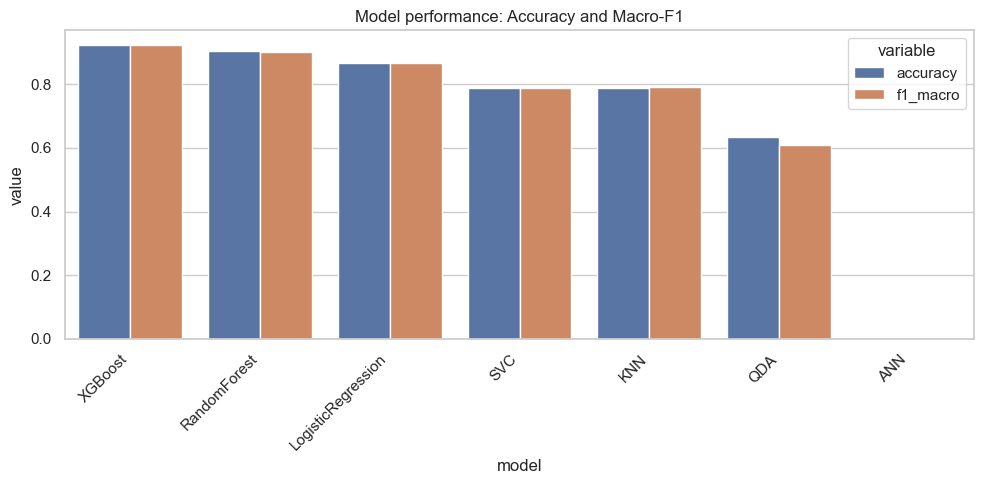

In [102]:
# Performance summary (accuracy + macro-F1 if available)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# collect models
models = {}
for name, info in (results.items() if 'results' in globals() else {}):
    model = info['model'] if isinstance(info, dict) and 'model' in info else info
    models[name] = model

rows = []
for name, model in models.items():
    # choose test set
    X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
    y_test_use = globals().get('y_test')
    if X_test_use is None or y_test_use is None:
        continue
    try:
        y_pred = model.predict(X_test_use)
        acc = accuracy_score(y_test_use, y_pred)
        p = precision_score(y_test_use, y_pred, average='macro', zero_division=0)
        r = recall_score(y_test_use, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test_use, y_pred, average='macro', zero_division=0)
    except Exception:
        acc = np.nan; p = np.nan; r = np.nan; f1 = np.nan
    rows.append({'model': name, 'accuracy': acc, 'precision_macro': p, 'recall_macro': r, 'f1_macro': f1})

perf_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(perf_df)

# bar chart
plt.figure(figsize=(10,5))
sns.barplot(data=perf_df.melt(id_vars='model', value_vars=['accuracy','f1_macro']),
            x='model', y='value', hue='variable')
plt.xticks(rotation=45, ha='right')
plt.title('Model performance: Accuracy and Macro-F1')
plt.tight_layout()
plt.show()

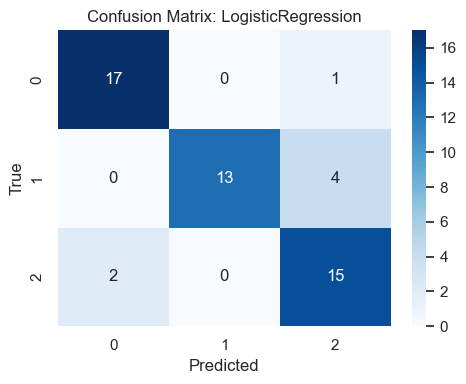

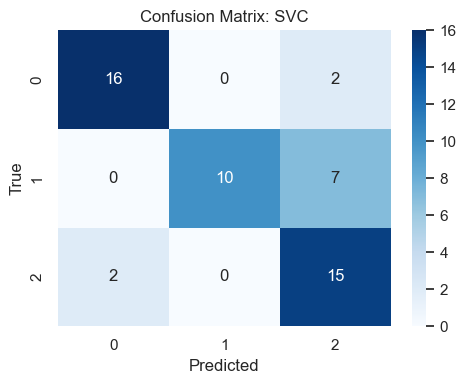

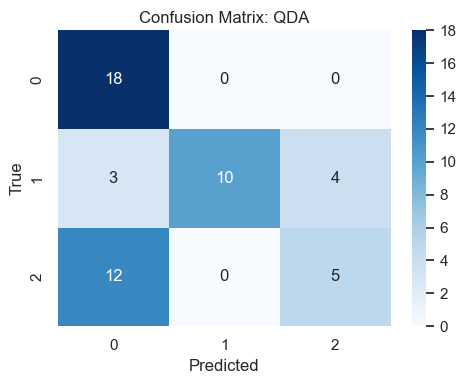

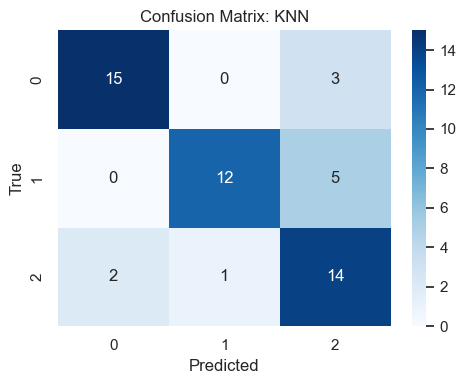

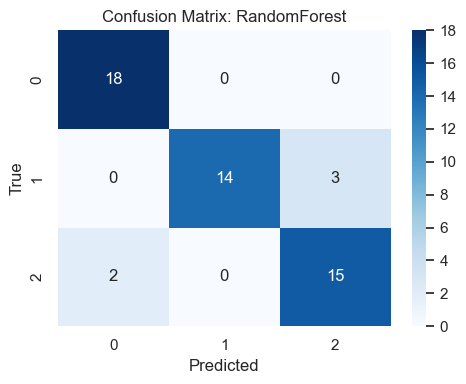

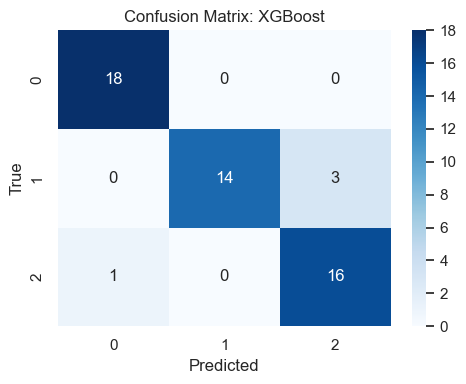

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Skipping ANN: Classification metrics can't handle a mix of multiclass and continuous-multioutput targets


In [103]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found in namespace.")
else:
    for name, model in models.items():
        try:
            y_pred = model.predict(X_test_use)
            cm = confusion_matrix(y_test_use, y_pred)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix: {name}')
            plt.xlabel('Predicted'); plt.ylabel('True')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Skipping {name}: {e}")

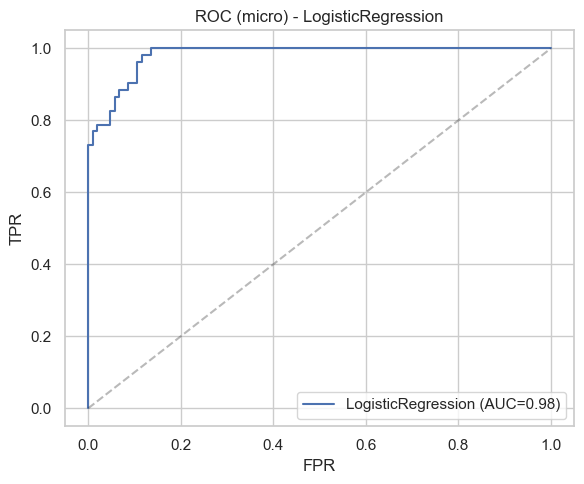

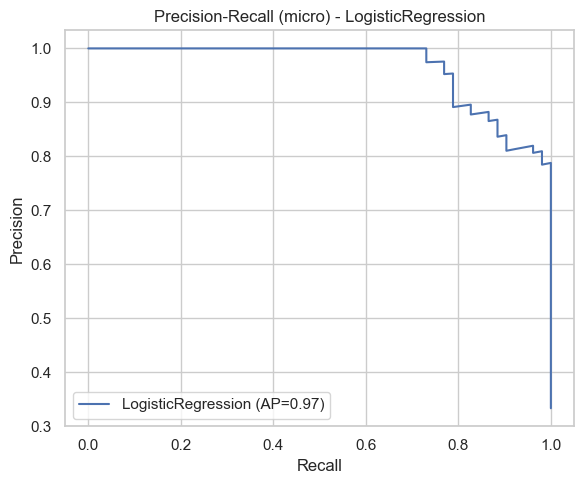

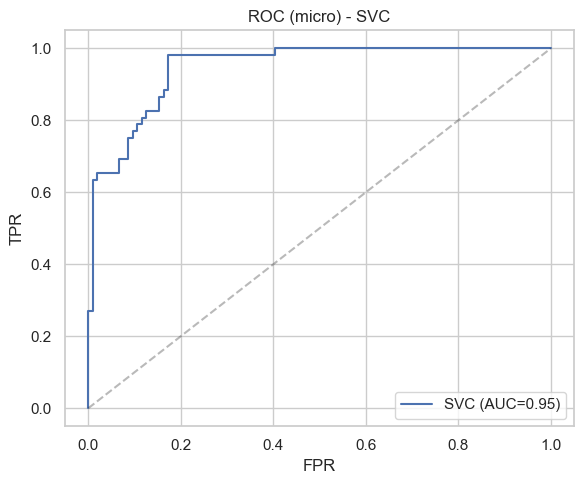

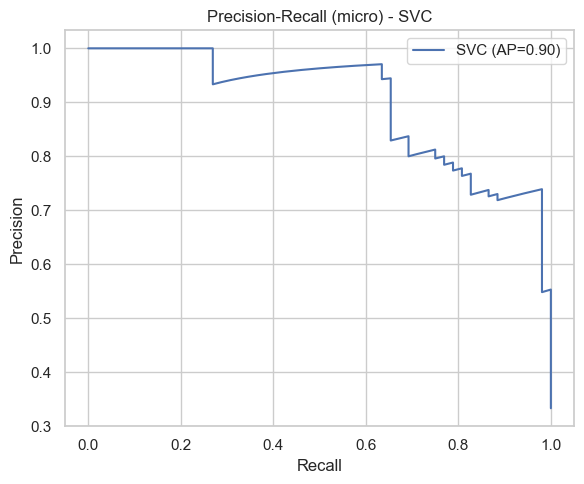

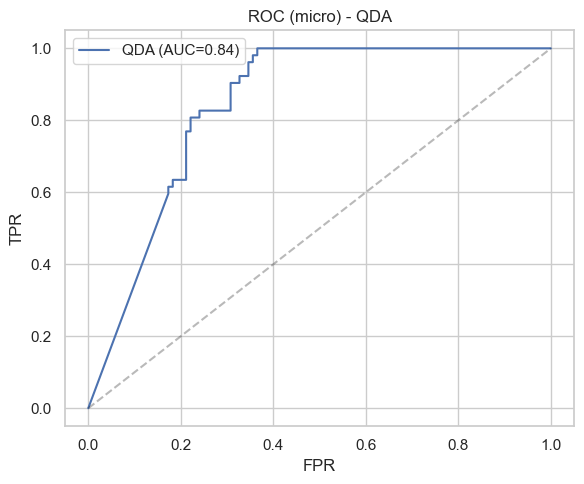

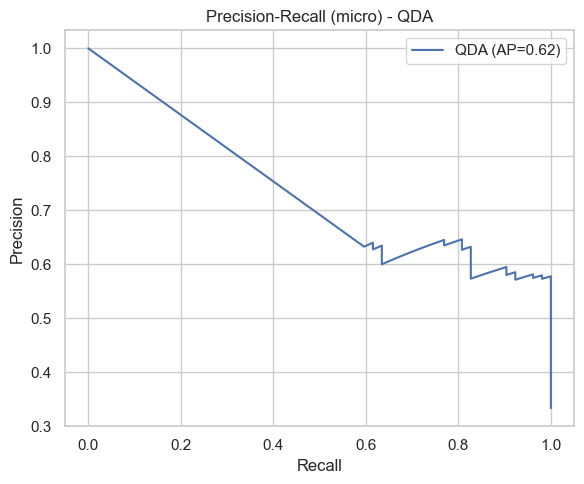

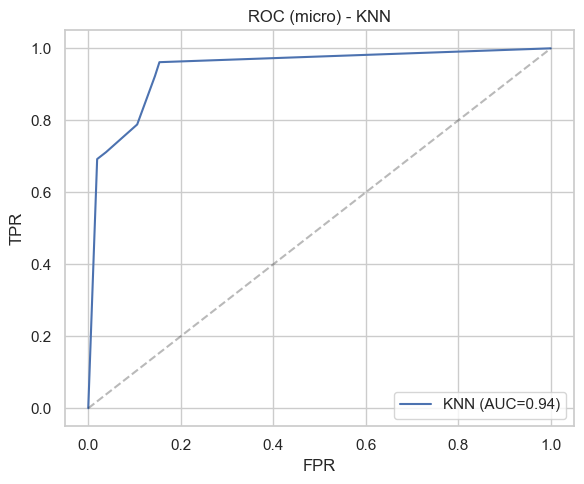

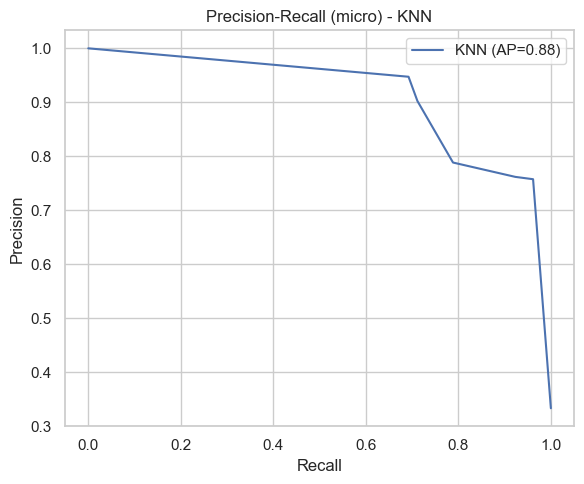

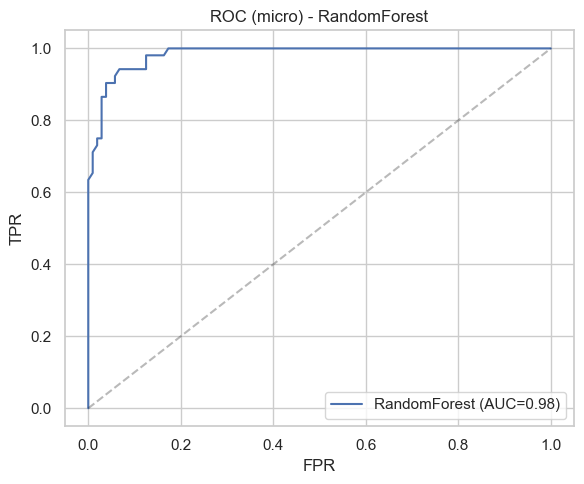

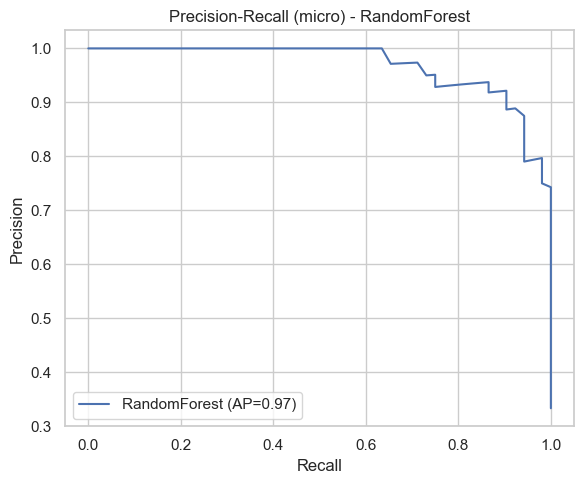

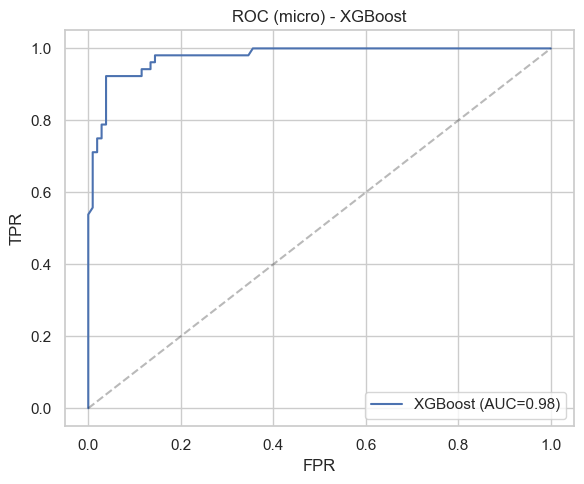

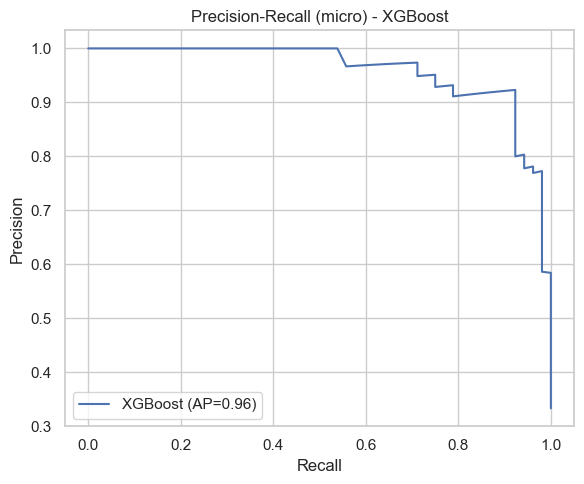

No prob/score for ANN, skipping ROC/PR.


In [104]:
# ROC & PR curves (multi-class micro-average). Requires predict_proba or decision_function.
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    print("X_test / y_test not found.")
else:
    classes = np.unique(y_test_use)
    y_bin = label_binarize(y_test_use, classes=classes)
    for name, model in models.items():
        try:
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test_use)
            elif hasattr(model, 'decision_function'):
                y_score = model.decision_function(X_test_use)
            else:
                print(f"No prob/score for {name}, skipping ROC/PR.")
                continue
            # micro-average ROC
            fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'k--', alpha=0.3)
            plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()

            # PR curve (micro)
            precision, recall, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
            ap = average_precision_score(y_bin, y_score, average='micro')
            plt.figure(figsize=(6,5))
            plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')
            plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'Precision-Recall (micro) - {name}')
            plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Error plotting ROC/PR for {name}: {e}")

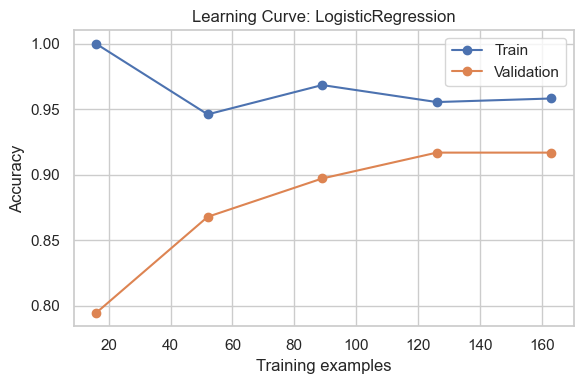

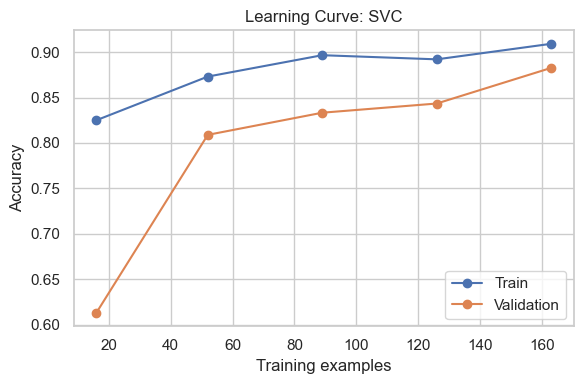

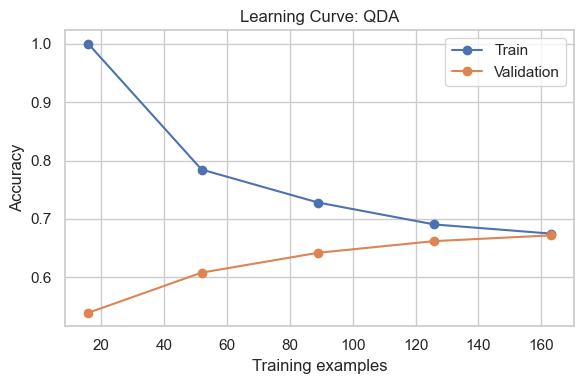

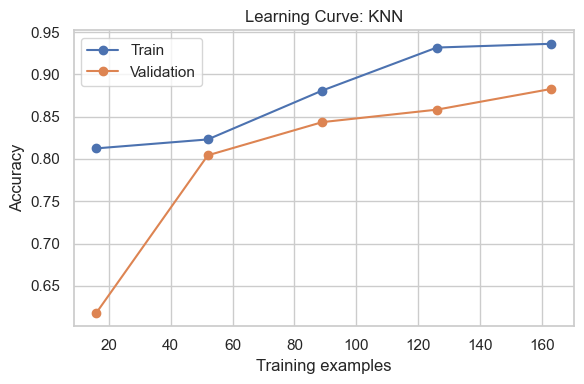

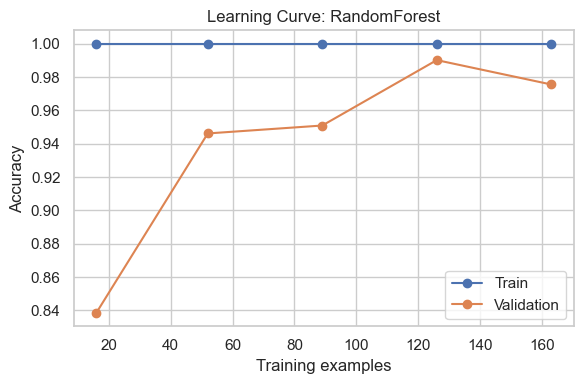

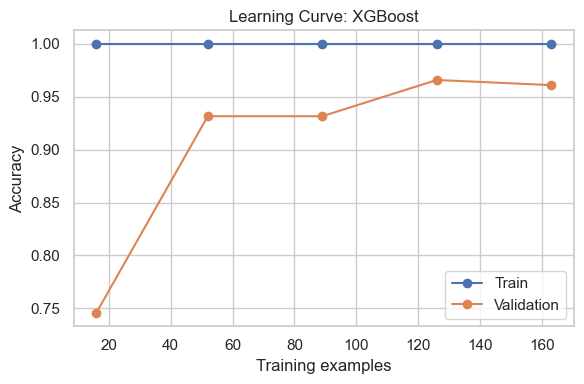

Learning curve failed for ANN: list index out of range


In [106]:
# Learning curves per model (may be slow)
from sklearn.model_selection import learning_curve
X_train_use = globals().get('X_train_scaled', globals().get('X_train'))
y_train_use = globals().get('y_train')
if X_train_use is None or y_train_use is None:
    print("X_train / y_train not found.")
else:
    for name, model in models.items():
        try:
            train_sizes, train_scores, val_scores = learning_curve(model, X_train_use, y_train_use, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy')
            plt.figure(figsize=(6,4))
            plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
            plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
            plt.title(f'Learning Curve: {name}')
            plt.xlabel('Training examples'); plt.ylabel('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Learning curve failed for {name}: {e}")

Skipping ANN: no `predict_proba` or `decision_function`.


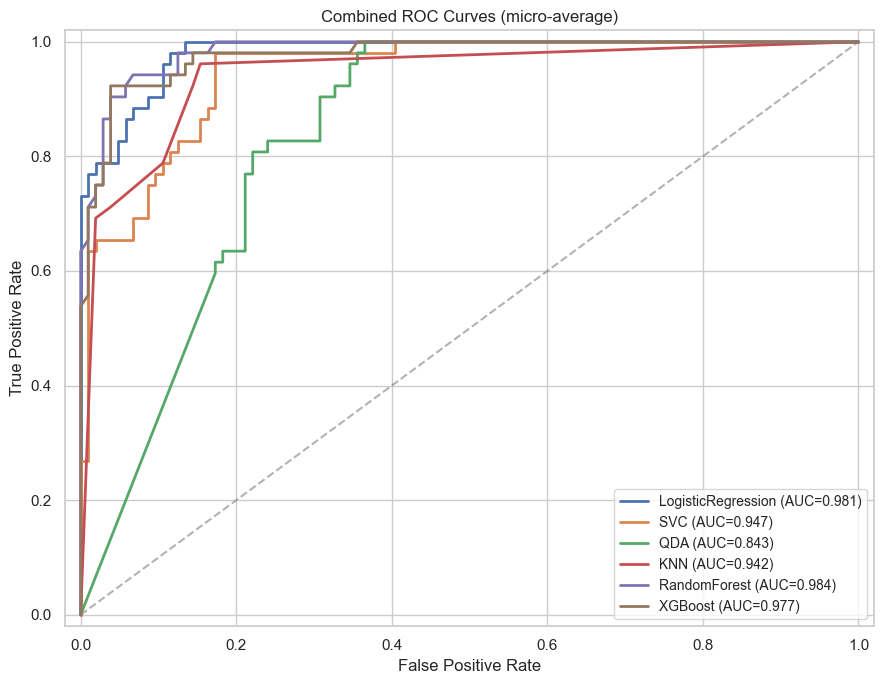

In [107]:
# Combined ROC curves (micro-average) for all models in `results`
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# collect models
models = {}
if 'results' in globals():
    for name, info in results.items():
        model = info['model'] if isinstance(info, dict) and 'model' in info else info
        models[name] = model
else:
    raise RuntimeError("`results` not found in namespace.")

# test data (prefer scaled if available)
X_test_use = globals().get('X_test_scaled', globals().get('X_test'))
y_test_use = globals().get('y_test')
if X_test_use is None or y_test_use is None:
    raise RuntimeError("`X_test` / `y_test` not found. Define them before running this cell.")

# binarize labels for multiclass micro-average
classes = np.unique(y_test_use)
y_bin = label_binarize(y_test_use, classes=classes)

plt.figure(figsize=(9,7))
sns.set_style("whitegrid")

for name, model in models.items():
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_test_use)
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_test_use)
            if y_score.ndim == 1:
                y_score = np.vstack([1 - y_score, y_score]).T
        else:
            print(f"Skipping {name}: no `predict_proba` or `decision_function`.")
            continue

        fpr, tpr, _ = roc_curve(y_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
    except Exception as e:
        print(f"Error for {name}: {e}")

plt.plot([0,1], [0,1], linestyle='--', color='gray', alpha=0.6)
plt.xlim([-0.02,1.02]); plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves (micro-average)')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## Feature Important

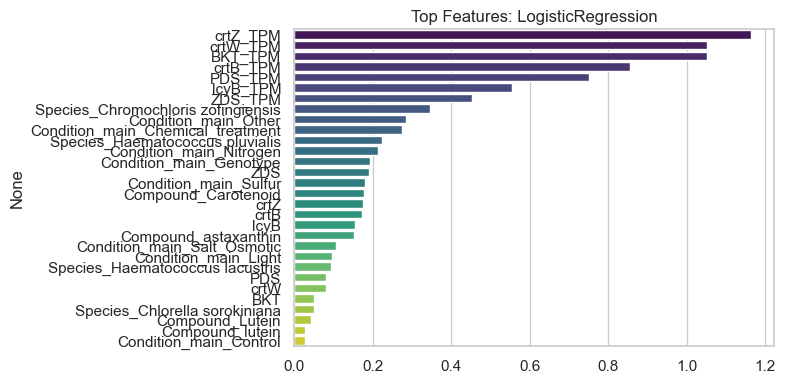

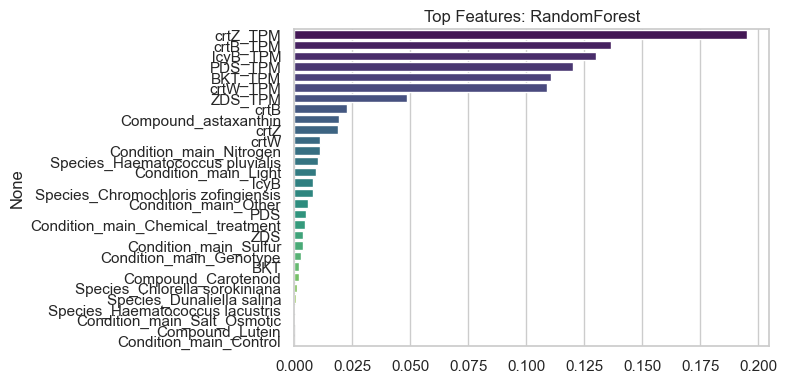

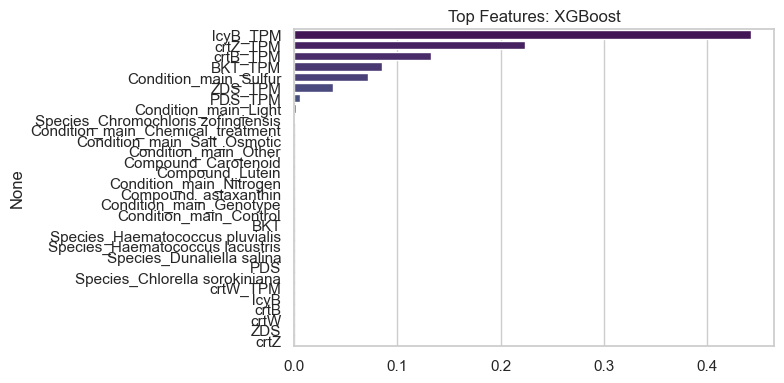

In [105]:
# Feature importances
feature_names = None
if 'X_train' in globals() and hasattr(X_train, 'columns'):
    feature_names = X_train.columns
elif 'X_encoded' in globals() and hasattr(X_encoded, 'columns'):
    feature_names = X_encoded.columns

for name, model in models.items():
    try:
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        elif hasattr(model, 'coef_'):
            imp = np.abs(model.coef_).mean(axis=0) if model.coef_.ndim>1 else np.abs(model.coef_)
        else:
            continue
        if feature_names is None:
            feature_names = [f'F{i}' for i in range(len(imp))]
        imp_df = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f'Top Features: {name}')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"Feature importances not available for {name}: {e}")

## Old model code

In [52]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dictionary to store models and their performance
imputation_models = {}

# 1. Logistic Regression
print("=" * 50)
print("Training Logistic Regression")
print("=" * 50)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_scores = cross_val_score(lr, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {lr_scores}")
print(f"Mean CV Accuracy: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
lr.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Logistic Regression'] = lr

# 2. K-Nearest Neighbors
print("\n" + "=" * 50)
print("Training K-Nearest Neighbors")
print("=" * 50)
knn = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {knn_scores}")
print(f"Mean CV Accuracy: {knn_scores.mean():.4f} (+/- {knn_scores.std():.4f})")
knn.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['KNN'] = knn

# 3. Random Forest
print("\n" + "=" * 50)
print("Training Random Forest")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {rf_scores}")
print(f"Mean CV Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
rf.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['Random Forest'] = rf

# 4. XGBoost
print("\n" + "=" * 50)
print("Training XGBoost")
print("=" * 50)
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_scores = cross_val_score(xgb, X_labeled_scaled, y_labeled_encoded, cv=5)
print(f"Cross-validation scores: {xgb_scores}")
print(f"Mean CV Accuracy: {xgb_scores.mean():.4f} (+/- {xgb_scores.std():.4f})")
xgb.fit(X_labeled_scaled, y_labeled_encoded)
imputation_models['XGBoost'] = xgb

# Summary of model performance
print("\n" + "=" * 50)
print("Model Performance Summary")
print("=" * 50)
model_scores = {
    'Logistic Regression': lr_scores.mean(),
    'KNN': knn_scores.mean(),
    'Random Forest': rf_scores.mean(),
    'XGBoost': xgb_scores.mean()
}
for model_name, score in sorted(model_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {score:.4f}")

Training Logistic Regression


NameError: name 'X_labeled_scaled' is not defined

#### Tune Logistic Regression

In [ ]:
print("=" * 60)
print("TUNING LOGISTIC REGRESSION")
print("=" * 60)

# Define hyperparameter grid
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization strength
    'penalty': ['l2'],  # L2 regularization
    'solver': ['lbfgs', 'liblinear'],  # Solver algorithms
    'max_iter': [1000, 5000, 10000]
}

# GridSearchCV for exhaustive search
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming GridSearchCV for Logistic Regression...")
lr_grid.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best CV Accuracy: {lr_grid.best_score_:.4f}")

# Get best model
lr_best = lr_grid.best_estimator_
lr_best_pred = lr_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, lr_best_pred):.4f}")

# Store best model
imputation_models['LR_tuned'] = lr_best
model_scores['LR_tuned'] = lr_grid.best_score_

TUNING LOGISTIC REGRESSION

Performing GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.6457
Training Accuracy: 0.6914


#### Tune K-Nearest Neighbors

In [ ]:
print("\n" + "=" * 60)
print("TUNING K-NEAREST NEIGHBORS")
print("=" * 60)

# Define hyperparameter grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Algorithm
    'p': [1, 2]  # Minkowski distance power (1=Manhattan, 2=Euclidean)
}

# RandomizedSearchCV for faster tuning (KNN has many params)
knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for KNN...")
knn_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {knn_random.best_params_}")
print(f"Best CV Accuracy: {knn_random.best_score_:.4f}")

# Get best model
knn_best = knn_random.best_estimator_
knn_best_pred = knn_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, knn_best_pred):.4f}")

# Store best model
imputation_models['KNN_tuned'] = knn_best
model_scores['KNN_tuned'] = knn_random.best_score_


TUNING K-NEAREST NEIGHBORS

Performing RandomizedSearchCV for KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 15, 'algorithm': 'kd_tree'}
Best CV Accuracy: 0.5657
Training Accuracy: 0.7429


#### Tune Random Forest

In [ ]:
print("\n" + "=" * 60)
print("TUNING RANDOM FOREST")
print("=" * 60)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [50, 100, 200, 300],  # Number of trees
    'max_depth': [5, 10, 15, 20, None],  # Max depth of trees
    'min_samples_split': [2, 5, 10, 20],  # Min samples to split
    'min_samples_leaf': [1, 2, 4, 8],  # Min samples in leaf
    'max_features': ['sqrt', 'log2'],  # Features per split
    'bootstrap': [True, False]  # Use bootstrap
}

# RandomizedSearchCV for efficiency
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nPerforming RandomizedSearchCV for Random Forest...")
rf_random.fit(X_labeled_scaled, y_labeled_encoded)

print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV Accuracy: {rf_random.best_score_:.4f}")

# Get best model
rf_best = rf_random.best_estimator_
rf_best_pred = rf_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, rf_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
feature_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance.head(10))

# Store best model
imputation_models['RF_tuned'] = rf_best
model_scores['RF_tuned'] = rf_random.best_score_


TUNING RANDOM FOREST

Performing RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': True}
Best CV Accuracy: 0.6571
Training Accuracy: 0.8514

Feature Importance (Top 10):
                              Feature  Importance
2                          TPM of BKT    0.263147
3                       TPM of CrtR-b    0.240393
6                Condition_main_Light    0.155678
1                              CrtR-b    0.076202
7              Condition_main_Light\n    0.055435
4   Condition_main_Chemical_treatment    0.044774
12                Compound_Carotenoid    0.034485
0                                 BKT    0.033425
14               Compound_astaxanthin    0.030727
8             Condition_main_Nitrogen    0.030054


#### Tune XGBoost

In [ ]:
print("\n" + "=" * 60)
print("TUNING XGBOOST")
print("=" * 60)

# Two-stage tuning for XGBoost (recommended approach)
# Stage 1: Tune tree-specific parameters
xgb_params_1 = {
    'max_depth': [3, 5, 7, 9],  # Tree depth
    'min_child_weight': [1, 3, 5, 7],  # Min child weight
    'subsample': [0.6, 0.8, 1.0],  # Row sampling
    'colsample_bytree': [0.6, 0.8, 1.0]  # Column sampling
}

print("\nStage 1: Tuning tree parameters...")
xgb_random_1 = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    xgb_params_1,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_1.fit(X_labeled_scaled, y_labeled_encoded)
print(f"Best tree parameters: {xgb_random_1.best_params_}")
print(f"Best CV Accuracy: {xgb_random_1.best_score_:.4f}")

# Stage 2: Tune boosting parameters with best tree params
best_tree_params = xgb_random_1.best_params_

xgb_params_2 = {
    'n_estimators': [100, 200, 300, 500],  # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],  # Learning rate
    'gamma': [0, 0.1, 0.5, 1.0]  # Min loss reduction
}

print("\nStage 2: Tuning boosting parameters...")
xgb_random_2 = RandomizedSearchCV(
    XGBClassifier(
        max_depth=best_tree_params['max_depth'],
        min_child_weight=best_tree_params['min_child_weight'],
        subsample=best_tree_params['subsample'],
        colsample_bytree=best_tree_params['colsample_bytree'],
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_params_2,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random_2.fit(X_labeled_scaled, y_labeled_encoded)
print(f"\nBest boosting parameters: {xgb_random_2.best_params_}")
print(f"Best CV Accuracy: {xgb_random_2.best_score_:.4f}")

# Get best XGBoost model
xgb_best = xgb_random_2.best_estimator_
xgb_best_pred = xgb_best.predict(X_labeled_scaled)
print(f"Training Accuracy: {accuracy_score(y_labeled_encoded, xgb_best_pred):.4f}")

# Feature importance
print("\nFeature Importance (Top 10):")
xgb_importance = pd.DataFrame({
    'Feature': X_labeled_encoded.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_importance.head(10))

# Store best model
imputation_models['XGB_tuned'] = xgb_best
model_scores['XGB_tuned'] = xgb_random_2.best_score_


TUNING XGBOOST

Stage 1: Tuning tree parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best tree parameters: {'subsample': 0.6, 'min_child_weight': 3, 'max_depth': 7, 'colsample_bytree': 0.6}
Best CV Accuracy: 0.6629

Stage 2: Tuning boosting parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best boosting parameters: {'n_estimators': 100, 'learning_rate': 0.01, 'gamma': 0}
Best CV Accuracy: 0.6514
Training Accuracy: 0.8229

Feature Importance (Top 10):
                              Feature  Importance
6                Condition_main_Light    0.211254
2                          TPM of BKT    0.118518
12                Compound_Carotenoid    0.108747
3                       TPM of CrtR-b    0.096739
1                              CrtR-b    0.094204
0                                 BKT    0.094063
4   Condition_main_Chemical_treatment    0.077700
14               Compound_astaxanthin    0.072615
7              Condition_main_Light\n  

In [ ]:
# make Series so pandas aligns by model name
original_sr = pd.Series(original_scores)
tuned_sr = pd.Series(tuned_scores)

comparison_df = pd.concat([original_sr, tuned_sr], axis=1)
comparison_df.columns = ['Original', 'Tuned']

comparison_df['Improvement'] = comparison_df['Tuned'] - comparison_df['Original']
comparison_df['Improvement %'] = (comparison_df['Improvement'] /
                                  comparison_df['Original'].replace(0, np.nan) * 100).fillna(0)

print(comparison_df)
print(f"\nBest Original Model: {max(original_scores, key=original_scores.get)} ({max(original_scores.values()):.4f})")
print(f"Best Tuned Model: {max(tuned_scores, key=tuned_scores.get)} ({max(tuned_scores.values()):.4f})")

                     Original     Tuned  Improvement  Improvement %
Logistic Regression  0.497143  0.645714     0.148571      29.885057
KNN                  0.508571  0.565714     0.057143      11.235955
Random Forest        0.571429  0.657143     0.085714      15.000000
XGBoost              0.542857  0.651429     0.108571      20.000000

Best Original Model: Random Forest (0.5714)
Best Tuned Model: Random Forest (0.6571)


In [ ]:
# Use the best model (choose the one with highest CV score)
best_model_name = max(model_scores, key=model_scores.get)
best_model = imputation_models[best_model_name]

print(f"Using {best_model_name} for imputation (Accuracy: {model_scores[best_model_name]:.4f})")

# Predict missing labels
y_unlabeled_predicted_encoded = best_model.predict(X_unlabeled_scaled)

# Decode predictions back to original label names
y_unlabeled_predicted = label_encoder.inverse_transform(y_unlabeled_predicted_encoded)

print(f"\nPredicted labels for missing values:")
print(f"Distribution of imputed labels:")
unique, counts = np.unique(y_unlabeled_predicted, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

Using RF_tuned for imputation (Accuracy: 0.6571)

Predicted labels for missing values:
Distribution of imputed labels:
  High: 1
  Low: 44


Label distribution comparison:

Before imputation (labeled data only):
Label
Low       0.371429
Medium    0.314286
High      0.314286
Name: proportion, dtype: float64

After imputation (full dataset):
Label
Low       0.495455
High      0.254545
Medium    0.250000
Name: proportion, dtype: float64


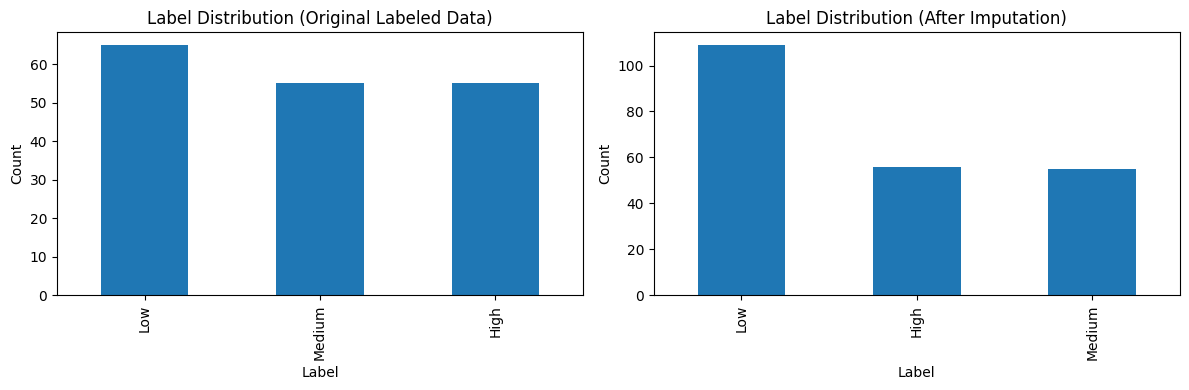

In [ ]:
# Compare distributions before and after
print("Label distribution comparison:")
print("\nBefore imputation (labeled data only):")
print(labeled_df['Label'].value_counts(normalize=True))
print("\nAfter imputation (full dataset):")
print(df_imputed['Label'].value_counts(normalize=True))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original labeled data
labeled_df['Label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Label Distribution (Original Labeled Data)')
axes[0].set_ylabel('Count')

# After imputation
df_imputed['Label'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Label Distribution (After Imputation)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
df_imputed.shape

(220, 10)

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 0 to 223
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Species         220 non-null    object 
 1   Strain          202 non-null    object 
 2   Bioproject      220 non-null    object 
 3   Condition_main  220 non-null    object 
 4   Compound        220 non-null    object 
 5   Label           220 non-null    object 
 6   BKT             220 non-null    float64
 7   CrtR-b          220 non-null    float64
 8   TPM of BKT      220 non-null    float64
 9   TPM of CrtR-b   220 non-null    float64
dtypes: float64(4), object(6)
memory usage: 27.0+ KB


In [ ]:
target_col = 'Label'
cols_to_drop = ['Species', 'Strain', 'Bioproject']  # drop identifiers/non-features

In [ ]:
X = df_imputed.drop(columns=cols_to_drop + [target_col])
y = df_imputed[target_col]

In [ ]:
# encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# one-hot encode categorical features (same approach as before)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
#Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
#Fearure Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

X_train shape: (140, 15), X_test shape: (35, 15)


In [ ]:
#Collect Models results
results = {}